# MT-GINO: Evaluation notebook

Loads the .pt checkpoint produced by  and evaluates both decoders:

- GNO decoder: particle-state queries --> 10-channel delta update.
- MLP decoder: fdom grid queries --> 3-channel velocity field.

Default evaluation uses the MLP decoder on stored grid-query coordinates from the processed .npz. Dense super-resolution slice queries are available as a separate visualization helper.


In [1]:
import os, json, math, time, inspect
from pathlib import Path
from typing import Dict, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn

# neuralop imports
from neuralop.layers.gno_block import GNOBlock
from neuralop.models import FNO

# ----------------------------------------------------------------------
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------------------
# Paths – adjust these to your setup
REPO_ROOT = Path.cwd()   # assuming notebook is in project root
RESULTS_DIR = REPO_ROOT / "Pt_Model/sharedlatent_GINO_4"
PLOT_DIR = REPO_ROOT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RESULTS_DIR / "gino_evolution_sharedlatent_4_best_model.pt"
DATASET_PATH = REPO_ROOT / "Processed_Data" / "processed_data_split3/particle_evolution_dataset.npz"

RUN_TAG = "gino_evolution_sharedlatent_4"          # must match training tag
HISTORY_PATH = RESULTS_DIR / f"{RUN_TAG}_history.json"

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Dataset:    {DATASET_PATH}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Device: cuda
Checkpoint: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/Pt_Model/sharedlatent_GINO_4/gino_evolution_sharedlatent_4_best_model.pt
Dataset:    /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/Processed_Data/processed_data_split3/particle_evolution_dataset.npz


In [2]:
# Load checkpoint
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
cfg = checkpoint["config"]

# Load dataset (only metadata arrays; full data is accessed later via memory mapping)
data = np.load(DATASET_PATH, allow_pickle=True)

# Memory‑mapped arrays (needed by build_batch)
inputs_t            = np.asarray(data["inputs_t"], dtype=np.float32)
targets_delta_norm  = np.asarray(data["targets_residual_norm" if "targets_residual_norm" in data.files else "targets_delta_norm"], dtype=np.float32)
targets_delta_raw   = np.asarray(data["targets_delta"], dtype=np.float32)

# Feature / target names
feature_names_all = [str(x) for x in data["feature_names"].tolist()]
feature_names      = checkpoint["feature_names"]          # subset used
target_names       = checkpoint["target_names"]           # delta targets
field_target_names = checkpoint["field_target_names"]     # field outputs

active_input_indices = [feature_names_all.index(n) for n in feature_names]
coord_indices        = [feature_names_all.index(n) for n in ("x", "y", "z")]
velocity_indices     = [feature_names_all.index(n) for n in ("u_x", "u_y", "u_z")]
gradient_indices     = [feature_names_all.index(f"gradU_{i}{j}") for i in "xyz" for j in "xyz"]
state_indices        = [feature_names_all.index(n) for n in ("x", "y", "z", "Gamma_x", "Gamma_y", "Gamma_z", "sigma")]

# Normalisation (from checkpoint)
input_mean  = checkpoint["input_mean"]
input_std   = checkpoint["input_std"]
target_mean = checkpoint.get("target_mean", data["residual_mean" if "residual_mean" in data.files else "out_mean"])
target_std  = checkpoint.get("target_std", data["residual_std" if "residual_std" in data.files else "out_std"])
raw_delta_mean = data["raw_delta_mean" if "raw_delta_mean" in data.files else "out_mean"]
raw_delta_std  = data["raw_delta_std" if "raw_delta_std" in data.files else "out_std"]
field_mean  = checkpoint["field_mean"]
field_std   = checkpoint["field_std"]
coord_min   = checkpoint["coord_min"]
coord_span  = checkpoint["coord_span"]

# Pair / split info
frame_ranges  = list(data["pair_ranges"])
frame_contexts = list(data["pair_contexts"])
train_ids = data["train_pair_ids"]
val_ids   = data["val_pair_ids"]
test_ids  = data["test_pair_ids"]

# Precomputed field grids
query_coords_all  = data["query_coords"]
targets_field_norm = data["targets_velocity_field_norm"]
field_mask        = data["field_query_mask"]

global_condition_channels = cfg["global_condition_channels"]
delta_channels = len(target_names)
field_channels = len(field_target_names)

print("Features used:", feature_names)
print("Delta targets:", target_names)
print("Field targets:", field_target_names)
print("Test pairs:", len(test_ids))

Features used: ['u_x', 'u_y', 'u_z', 'sigma', 'geom_dist', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'gradU_xx', 'gradU_xy', 'gradU_xz', 'gradU_yx', 'gradU_yy', 'gradU_yz', 'gradU_zx', 'gradU_zy', 'gradU_zz']
Delta targets: ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma']
Field targets: ['u_x', 'u_y', 'u_z', 'dUx_dx', 'dUx_dy', 'dUx_dz', 'dUy_dx', 'dUy_dy', 'dUy_dz', 'dUz_dx', 'dUz_dy', 'dUz_dz']
Test pairs: 300


In [3]:
def as_context(obj):
    """Convert a numpy structured scalar / void to a plain dictionary."""
    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "item"):
        item = obj.item()
        if isinstance(item, dict):
            return item
    # fallback: numpy void → dict
    return dict(obj)

def make_gnoblock(in_channels, out_channels, radius):
    """Create a GNO block exactly as used during training."""
    from neuralop.layers.gno_block import GNOBlock  # ensure import
    kwargs = dict(
        in_channels=in_channels,
        out_channels=out_channels,
        coord_dim=3,
        radius=float(radius),
        transform_type="linear",
        reduction="mean",
        pos_embedding_type="transformer",
        pos_embedding_channels=12,
        channel_mlp_layers=[out_channels, out_channels, out_channels],
    )
    # remove arguments not accepted by the installed version of GNOBlock
    accepted = set(inspect.signature(GNOBlock.__init__).parameters)
    if "use_torch_scatter_reduce" in accepted:
        kwargs["use_torch_scatter_reduce"] = False
    if "use_open3d_neighbor_search" in accepted:
        kwargs["use_open3d_neighbor_search"] = False
    return GNOBlock(**{k: v for k, v in kwargs.items() if k in accepted})

In [4]:
# --- Helper: sinusoidal positional encoding (same as training) ---
def positional_encoding(coords, num_frequencies: int):
    if num_frequencies <= 0:
        return coords
    freqs = (2.0 ** torch.arange(num_frequencies, device=coords.device, dtype=coords.dtype)).view(1, 1, -1)
    angles = coords.unsqueeze(-1) * freqs * math.pi
    return torch.cat([coords, torch.sin(angles).flatten(-2), torch.cos(angles).flatten(-2)], dim=-1)

def euler_baseline_from_batch(batch):
    state_t = torch.tensor(batch["state_phys_raw"], device=DEVICE, dtype=torch.float32)
    u_true = torch.tensor(batch["velocity_phys_raw"], device=DEVICE, dtype=torch.float32)
    gradU_true = torch.tensor(batch["gradU_phys_raw"], device=DEVICE, dtype=torch.float32).reshape(-1, 3, 3)
    dt = torch.tensor(float(batch.get("dt", 0.0034)), device=DEVICE, dtype=torch.float32)
    physics_dx = dt * u_true
    physics_dgamma = dt * torch.einsum("nij,nj->ni", gradU_true, state_t[:, 3:6])
    return state_t, physics_dx, physics_dgamma

def reconstruct_next_state_from_residual(batch, residual_pred_norm):
    residual_pred_phys = residual_pred_norm[:, :7] * target_std_t + target_mean_t
    state_t, physics_dx, physics_dgamma = euler_baseline_from_batch(batch)
    state_tp1_pred = state_t.clone()
    state_tp1_pred[:, :3] += physics_dx + residual_pred_phys[:, :3]
    state_tp1_pred[:, 3:6] += physics_dgamma + residual_pred_phys[:, 3:6]
    state_tp1_pred[:, 6] += residual_pred_phys[:, 6]
    raw_delta = torch.tensor(batch["y_delta_raw"], device=DEVICE, dtype=torch.float32)[:, :7]
    state_tp1_true = state_t + raw_delta
    return state_tp1_pred, state_tp1_true, residual_pred_phys

def state_error_relative_l2(state_tp1_pred, state_tp1_true):
    num = torch.linalg.norm(state_tp1_pred - state_tp1_true, dim=1)
    den = torch.linalg.norm(state_tp1_true, dim=1).clamp_min(1e-8)
    return (num / den).mean()

# --- GINOSharedLatent (exact replication of the trained model) ---
class GINOSharedLatent(nn.Module):
    def __init__(self, in_channels, delta_channels, field_channels, global_channels, cfg):
        super().__init__()
        hidden = int(cfg["hidden_channels"])
        self.latent_res = int(cfg["latent_res"])
        self.query_pe_freqs = int(cfg["query_pos_encoding_frequencies"])
        self.hidden = hidden

        # Shared encoder
        self.lift = nn.Sequential(
            nn.Linear(in_channels, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.global_condition_mlp = nn.Sequential(
            nn.Linear(global_channels, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.encoder = make_gnoblock(hidden, hidden, cfg["gno_radius"])  # from Snippet 3

        # FNO processor
        modes = min(int(cfg["fno_modes"]), max(self.latent_res // 2, 1))
        self.fno = FNO(
            n_modes=(modes, modes, modes),
            in_channels=hidden, out_channels=hidden,
            hidden_channels=hidden, n_layers=int(cfg["fno_layers"]),
            positional_embedding=None
        )

        # ---------- Field decoder (MLP) ----------
        query_dim = 3 + 2 * 3 * self.query_pe_freqs   # same as training
        self.particle_pos_enc_proj = nn.Linear(query_dim, hidden)   # <-- NEW
        self.grid_pos_enc_proj = nn.Linear(query_dim, hidden)       # <-- NEW
        width = int(cfg["mlp_hidden"])
        layers = []
        for i in range(int(cfg["mlp_layers"])):
            layers += [nn.Linear((hidden + query_dim) if i == 0 else width, width), nn.GELU()]
        layers.append(nn.Linear(width, field_channels))
        self.field_decoder = nn.Sequential(*layers)

        # ---------- Delta decoder (cross‑attention) ----------
        self.particle_skip_proj = nn.Linear(hidden, hidden)
        self.particle_query_proj = nn.Linear(hidden, hidden)
        self.grid_kv_proj = nn.Linear(hidden, 2 * hidden)
        self.attn_dropout = nn.Dropout(0.0)
        self.attn_norm = nn.LayerNorm(hidden)
        self.delta_fusion = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.delta_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, delta_channels)
        )

        # Uncertainty weights
        self.log_delta_var = nn.Parameter(torch.zeros(()))
        self.log_field_var = nn.Parameter(torch.zeros(()))

    def apply_gno(self, block, source_coords, query_coords, source_features):
        return block(y=source_coords, x=query_coords, f_y=source_features)

    def encode_process(self, input_geom, latent_queries, x, global_params):
        base_latent = latent_queries[0]
        r = self.latent_res
        grids, flat_latents, particle_skips = [], [], []
        for b in range(x.shape[0]):
            h_raw = self.lift(x[b])
            latent = self.apply_gno(self.encoder,
                                    source_coords=input_geom[b],
                                    query_coords=base_latent,
                                    source_features=h_raw)
            if latent.ndim == 3:
                latent = latent.squeeze(0)
            grid = latent.reshape(r, r, r, -1).permute(3, 0, 1, 2).unsqueeze(0)
            cond = self.global_condition_mlp(global_params[b]).view(1, -1, 1, 1, 1)
            processed_grid = self.fno(grid + cond)
            processed_flat = processed_grid.squeeze(0).permute(1, 2, 3, 0).reshape(-1, processed_grid.shape[1])
            grids.append(processed_grid)
            flat_latents.append(processed_flat)
            particle_skips.append(self.particle_skip_proj(h_raw))
        return base_latent, grids, flat_latents, particle_skips

    def sample_grid(self, grid, queries):
        q = queries.clamp(0.0, 1.0)
        sample_grid = (q * 2.0 - 1.0).view(1, -1, 1, 1, 3)
        sampled = torch.nn.functional.grid_sample(grid, sample_grid,
                                                  align_corners=True, mode="bilinear")
        return sampled.squeeze(0).squeeze(-1).squeeze(-1).transpose(0, 1)

    def cross_attention(self, queries, keys, values):
        d = queries.shape[-1]
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(d)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        return torch.matmul(attn_weights, values)

    def forward(self, input_geom, latent_queries, output_queries, x, global_params):
        base_latent, grids, flat_latents, particle_skips = self.encode_process(
            input_geom, latent_queries, x, global_params)
        delta_outputs, field_outputs = [], []
        for b, (grid, flat_latent, skip) in enumerate(zip(grids, flat_latents, particle_skips)):
            # --- Delta decoder (cross‑attention) ---
            pos_enc = positional_encoding(input_geom[b].unsqueeze(0), self.query_pe_freqs).squeeze(0)
            q_base = skip + self.particle_pos_enc_proj(pos_enc)               # (N, hidden)
            q = self.particle_query_proj(q_base)                              # (N, hidden)

            grid_pos_enc = positional_encoding(base_latent.unsqueeze(0), self.query_pe_freqs).squeeze(0)
            kv_input = flat_latent + self.grid_pos_enc_proj(grid_pos_enc)     # (M, hidden)
            kv = self.grid_kv_proj(kv_input)                                  # (M, 2*hidden)
            k, v = kv[..., :self.hidden], kv[..., self.hidden:]

            particle_latent = self.cross_attention(q, k, v)                    # (N, hidden)
            particle_latent = self.attn_norm(particle_latent + q)
            fused = self.delta_fusion(torch.cat([particle_latent, skip], dim=-1))
            delta_outputs.append(self.delta_head(fused).unsqueeze(0))

            # --- Field decoder ---
            q_field = output_queries[b].clamp(0.0, 1.0)
            sampled = self.sample_grid(grid, q_field)
            field_out = self.field_decoder(torch.cat(
                [sampled, positional_encoding(q_field.unsqueeze(0), self.query_pe_freqs).squeeze(0)],
                dim=-1))
            field_outputs.append(field_out.unsqueeze(0))

        return torch.cat(delta_outputs, dim=0), torch.cat(field_outputs, dim=0)

# Helper to create latent grid queries (must match cfg["latent_res"])
def make_latent_queries(res, device=DEVICE):   # device now defaults to DEVICE
    line = torch.linspace(0.0, 1.0, res, dtype=torch.float32, device=device)
    xx, yy, zz = torch.meshgrid(line, line, line, indexing="ij")
    return torch.stack([xx, yy, zz], dim=-1).reshape(1, -1, 3)

# ----------------------------------------------------------------------
# Instantiate model and load weights, handling the _metadata key
model = GINOSharedLatent(len(feature_names), delta_channels, field_channels,
                         len(global_condition_channels), cfg).to(DEVICE)

state_dict = checkpoint["model_state_dict"]
state_dict.pop("_metadata", None)                     # remove non‑parameter key
model.load_state_dict(state_dict, strict=True)        # now matches exactly
model.eval()

print(f"Loaded {sum(p.numel() for p in model.parameters()):,} parameters.")

Loaded 14,769,173 parameters.


In [5]:
def normalize_xyz(arr):
    return np.clip((arr - coord_min) / coord_span, 0, 1).astype(np.float32)

def context_global_params(ctx):
    ctx = as_context(ctx)                         # <-- added
    freestream = np.asarray(ctx.get("freestream", [0,0,0])).reshape(-1)
    values = {
        "angle_of_attack": float(ctx.get("aoa_deg", 0)) / 45.0,
        "freestream_magnitude": float(np.linalg.norm(freestream)) / 10.0,
        "phase": float(ctx.get("phase_t", 0)),
    }
    return np.array([values[ch] for ch in global_condition_channels], dtype=np.float32)


def build_batch(pair_id, max_particles=4096, max_queries=4096):
    """Construct a batch dict for a single pair – matching training particle selection."""
    start, end = int(frame_ranges[pair_id][3]), int(frame_ranges[pair_id][4])
    raw = inputs_t[start:end]                         # (N_total, n_features) physical units

    # -- Particle selection: use the SAME strategy as training --
    ctx = as_context(frame_contexts[pair_id])
    case = str(ctx.get("case", "unknown"))
    n_total = raw.shape[0]
    # nmin for this case (minimum number of particles across all frames of this case)
    nmin = int(case_to_nmin.get(case, n_total))
    n_use = min(n_total, nmin, max_particles)          # exact same logic
    idx = np.arange(n_use, dtype=np.int64)             # take the FIRST n_use particles

    x_norm = (raw[idx][:, active_input_indices] - input_mean) / input_std
    x_norm = np.clip(np.nan_to_num(x_norm), -8.0, 8.0).astype(np.float32)

    coord_norm = normalize_xyz(raw[idx][:, coord_indices])

    # -- State channels (physical units) --
    gamma_x_idx = feature_names_all.index("Gamma_x")
    gamma_y_idx = feature_names_all.index("Gamma_y")
    gamma_z_idx = feature_names_all.index("Gamma_z")
    sigma_idx   = feature_names_all.index("sigma")

    state_phys = raw[idx][:, state_indices].astype(np.float32)             # (n_use, 7)
    velocity_phys = raw[idx][:, velocity_indices].astype(np.float32)
    gradU_phys = raw[idx][:, gradient_indices].astype(np.float32)

    # -- Field queries (random subsample as before, this is fine) --
    valid = np.flatnonzero(field_mask[pair_id])
    query_idx = np.random.choice(valid, min(len(valid), max_queries), replace=False)
    q_xyz = query_coords_all[pair_id, query_idx]
    y_field = targets_field_norm[pair_id, query_idx]

    # -- Global conditioning --
    g_params = context_global_params(ctx)

    # -- Normalised delta target --
    y_delta = targets_delta_norm[start:end][idx, :delta_channels]
    y_delta_raw = targets_delta_raw[start:end][idx, :delta_channels]

    return {
        "input_geom": torch.from_numpy(coord_norm).unsqueeze(0).to(DEVICE),
        "x": torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(DEVICE),
        "output_queries": torch.from_numpy(normalize_xyz(q_xyz)).unsqueeze(0).to(DEVICE),
        "global_params": torch.from_numpy(g_params).unsqueeze(0).to(DEVICE),
        "y_delta_norm": y_delta,
        "y_field_norm": y_field,
        "query_xyz_raw": q_xyz,
        "input_xyz_raw": raw[idx][:, coord_indices],
        "state_phys_raw": state_phys,
        "velocity_phys_raw": velocity_phys,
        "gradU_phys_raw": gradU_phys,
        "y_delta_raw": y_delta_raw,
        "dt": float(ctx.get("dt", 0.0034)),
    }


# def build_batch(pair_id, max_particles=4096, max_queries=4096):
#     """Construct a batch dict for a single pair using loaded memory‑mapped arrays."""
#     start, end = int(frame_ranges[pair_id][3]), int(frame_ranges[pair_id][4])
#     raw = inputs_t[start:end]                         # (N_total, n_features) physical units

#     # -- Particle input --
#     N = min(raw.shape[0], max_particles)
#     idx = np.random.choice(raw.shape[0], N, replace=False)

#     x_norm = (raw[idx][:, active_input_indices] - input_mean) / input_std
#     coord_norm = normalize_xyz(raw[idx][:, coord_indices])

#     x_norm = np.clip(np.nan_to_num(x_norm), -8.0, 8.0).astype(np.float32)   # <-- add this line

#     # -- State channels (physical units) --
#     # Indices in the full feature list
#     gamma_x_idx = feature_names_all.index("Gamma_x")
#     gamma_y_idx = feature_names_all.index("Gamma_y")
#     gamma_z_idx = feature_names_all.index("Gamma_z")
#     sigma_idx   = feature_names_all.index("sigma")

#     state_phys = np.column_stack([
#         raw[idx, coord_indices[0]],   # x
#         raw[idx, coord_indices[1]],   # y
#         raw[idx, coord_indices[2]],   # z
#         raw[idx, gamma_x_idx],
#         raw[idx, gamma_y_idx],
#         raw[idx, gamma_z_idx],
#         raw[idx, sigma_idx],
#     ]).astype(np.float32)             # (N, 7)

#     # -- Field queries --
#     valid = np.flatnonzero(field_mask[pair_id])
#     query_idx = np.random.choice(valid, min(len(valid), max_queries), replace=False)
#     q_xyz = query_coords_all[pair_id, query_idx]      # raw query coordinates
#     y_field = targets_field_norm[pair_id, query_idx]  # normalised field target

#     # -- Global conditioning --
#     ctx = as_context(frame_contexts[pair_id])
#     g_params = context_global_params(ctx)

#     # -- Normalised delta target (all channels) --
#     y_delta = targets_delta_norm[start:end][idx, :delta_channels]
    y_delta_raw = targets_delta_raw[start:end][idx, :delta_channels]

#     return {
#         "input_geom": torch.from_numpy(coord_norm).unsqueeze(0).to(DEVICE),
#         "x": torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(DEVICE),
#         "output_queries": torch.from_numpy(normalize_xyz(q_xyz)).unsqueeze(0).to(DEVICE),
#         "global_params": torch.from_numpy(g_params).unsqueeze(0).to(DEVICE),
#         "y_delta_norm": y_delta,
#         "y_field_norm": y_field,
#         "query_xyz_raw": q_xyz,
#         "input_xyz_raw": raw[idx][:, coord_indices],
#         "state_phys_raw": state_phys,    # <-- (N, 7) physical state
#     }

In [6]:
# Compute case_to_nmin from frame_ranges (works even if rollout arrays are missing)
case_to_nmin = {}
for pair_id in range(len(frame_ranges)):
    case = str(as_context(frame_contexts[pair_id]).get("case", ""))
    n = int(frame_ranges[pair_id][5])   # number of particles in this pair
    if case not in case_to_nmin or n < case_to_nmin[case]:
        case_to_nmin[case] = n
print("case_to_nmin from pairs:", case_to_nmin)

case_to_nmin from pairs: {'10deg_static_airfoil_10u_1p': 301, '11deg_static_airfoil_10u_1p': 301, '12deg_static_airfoil_10u_1p': 301, '14deg_static_airfoil_10u_1p': 301, '15deg_static_airfoil_10u_1p': 301, '16deg_static_airfoil_10u_1p': 301, '18deg_static_airfoil_10u_1p': 301, '20deg_static_airfoil_10u_1p': 301, '21deg_static_airfoil_10u_1p': 301, '22deg_static_airfoil_10u_1p': 301, '24deg_static_airfoil_10u_1p': 301, '25deg_static_airfoil_10u_1p': 301, '26deg_static_airfoil_10u_1p': 301, '27deg_static_airfoil_10u_1p': 301, '28deg_static_airfoil_10u_1p': 301, '30deg_static_airfoil_10u_1p': 301, '32deg_static_airfoil_10u_1p': 301}


In [7]:
@torch.no_grad()
def evaluate_field_norm_overall(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    pred_all, true_all = [], []
    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        _, field_pred = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              batch["output_queries"],
                              batch["x"],
                              batch["global_params"])
        field_pred = field_pred[0]          # (M, 12)
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        pred_all.append(field_pred.reshape(-1))
        true_all.append(y_field_norm.reshape(-1))

    pred_all = torch.cat(pred_all)
    true_all = torch.cat(true_all)
    rel = (torch.linalg.norm(pred_all - true_all) /
           torch.linalg.norm(true_all).clamp_min(1e-8)).item()
    return rel

norm_overall = evaluate_field_norm_overall()
print(f"Overall normalised field rel. L2 (12 channels): {norm_overall:.4f}")

Overall normalised field rel. L2 (12 channels): 0.2864


In [8]:
# Pre‑computed constants for field denormalisation
field_mean_vel = field_mean[:3]          # mean of u_x, u_y, u_z
field_std_vel  = field_std[:3]           # std  of u_x, u_y, u_z

# Ensure the normalisation tensors are defined (run this once)
target_mean_t = torch.tensor(target_mean[:7], dtype=torch.float32, device=DEVICE)
target_std_t  = torch.tensor(target_std[:7],  dtype=torch.float32, device=DEVICE)
field_mean_t  = torch.tensor(field_mean,       dtype=torch.float32, device=DEVICE)
field_std_t   = torch.tensor(field_std,        dtype=torch.float32, device=DEVICE)


@torch.no_grad()
def evaluate_test_set_global(max_pairs=None):
    """
    Returns:
        state_global  – overall physical relative L2 of the predicted next state
        field_global  – overall physical relative L2 of the velocity field (3 comp.)
    """
    ids = test_ids[:max_pairs] if max_pairs else test_ids

    # We'll accumulate concatenated physical state and field vectors
    state_pred_all, state_true_all = [], []
    field_pred_all, field_true_all = [], []

    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])

        # Remove batch dim
        delta_pred = delta_pred[0]    # (N, 10)
        field_pred = field_pred[0]    # (M, 12)

        # ---------- Physical quantities ----------
        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)

        state_pred_all.append(state_tp1_pred.reshape(-1))   # flatten each matrix
        state_true_all.append(state_tp1_true.reshape(-1))

        # Physical velocity field (only first 3 channels)
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        field_true_phys = y_field_norm * field_std_t + field_mean_t
        field_pred_phys = field_pred * field_std_t + field_mean_t
        vel_true = field_true_phys[:, :3].reshape(-1)
        vel_pred = field_pred_phys[:, :3].reshape(-1)
        field_pred_all.append(vel_pred)
        field_true_all.append(vel_true)

    state_pred_all = torch.cat(state_pred_all)
    state_true_all = torch.cat(state_true_all)
    field_pred_all = torch.cat(field_pred_all)
    field_true_all = torch.cat(field_true_all)

    state_global = (torch.linalg.norm(state_pred_all - state_true_all) /
                    torch.linalg.norm(state_true_all).clamp_min(1e-8)).item()
    field_global = (torch.linalg.norm(field_pred_all - field_true_all) /
                    torch.linalg.norm(field_true_all).clamp_min(1e-8)).item()

    return state_global, field_global

state_glob, field_glob = evaluate_test_set_global()
print(f"State overall physical rel. L2: {state_glob:.4f}")
print(f"Field overall physical rel. L2: {field_glob:.4f}")

State overall physical rel. L2: 0.0198
Field overall physical rel. L2: 0.1670


/tmp/ipykernel_13317/3841854547.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([state_errs, field_errs],


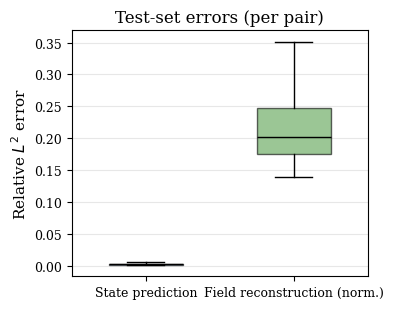

State error: mean=0.0104, median=0.0017
Field error (norm.): mean=0.2317, median=0.2019


In [9]:
# ----------------------------------------------------------------------
# Per‑pair evaluation with the ordered‑subset (training) protocol
# ----------------------------------------------------------------------
@torch.no_grad()
def evaluate_per_pair(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    state_errors = []      # per‑pair mean physical relative L2 error of the state
    field_errors_norm = []  # per‑pair normalized relative L2 error (matches training)

    for pid in ids:
        # build_batch now uses the first n_use particles (same as training)
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])

        # Remove batch dim
        delta_pred = delta_pred[0]      # (N, delta_channels)
        field_pred = field_pred[0]      # (M, 12)

        # ---------- state error (physical, per‑point average) ----------
        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)
        state_err = state_error_relative_l2(state_tp1_pred, state_tp1_true)
        state_errors.append(state_err.item())

        # ---------- field error (normalised, per‑pair overall) ----------
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        # Overall relative L2 for this pair (flattened), exactly as in training
        field_err = (torch.linalg.norm(field_pred.reshape(-1) - y_field_norm.reshape(-1)) /
                     torch.linalg.norm(y_field_norm.reshape(-1)).clamp_min(1e-8)).item()
        field_errors_norm.append(field_err)

    return np.array(state_errors), np.array(field_errors_norm)

state_errs, field_errs = evaluate_per_pair()

# ----------------------------------------------------------------------
# Publication‑ready boxplot
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.0,
    "grid.alpha": 0.3,
})

fig, ax = plt.subplots(figsize=(4, 3.2))
bp = ax.boxplot([state_errs, field_errs],
                labels=["State prediction", "Field reconstruction (norm.)"],
                widths=0.5, showfliers=False,
                patch_artist=True,
                medianprops=dict(color="black"))
for patch, color in zip(bp['boxes'], ["#4c78a8", "#59a14f"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Relative $L^2$ error")
ax.set_title("Test‑set errors (per pair)")
ax.grid(axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "test_rel_error_boxplot.pdf")
plt.show()

print(f"State error: mean={state_errs.mean():.4f}, median={np.median(state_errs):.4f}")
print(f"Field error (norm.): mean={field_errs.mean():.4f}, median={np.median(field_errs):.4f}")

/tmp/ipykernel_13317/600065979.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
/tmp/ipykernel_13317/600065979.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],


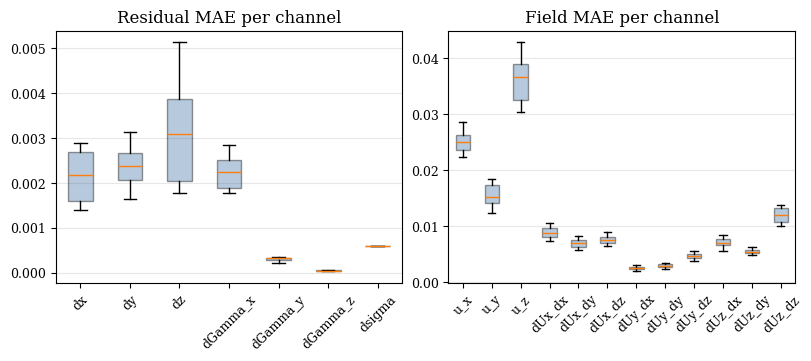

In [10]:
@torch.no_grad()
def channel_wise_mae(max_pairs=20):
    delta_mae, field_mae = [], []
    for pid in test_ids[:max_pairs]:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])

        # Remove batch dimension (model outputs (1, N, channels))
        delta_pred = delta_pred[0]      # (N, delta_channels)
        field_pred = field_pred[0]      # (M, field_channels)

        # Denormalise residual channels to physical units
        d_pred = (delta_pred * target_std_t + target_mean_t).cpu().numpy()
        y_delta_norm = torch.tensor(batch["y_delta_norm"], device=DEVICE)
        d_true = (y_delta_norm[:, :7] * target_std_t + target_mean_t).cpu().numpy()

        f_pred = (field_pred * field_std_t + field_mean_t).cpu().numpy()
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        f_true = (y_field_norm * field_std_t + field_mean_t).cpu().numpy()

        # Per‑pair mean absolute error, averaged over all points → (channels,)
        delta_mae.append(np.mean(np.abs(d_pred - d_true), axis=0))   # (delta_channels,)
        field_mae.append(np.mean(np.abs(f_pred - f_true), axis=0))   # (field_channels,)

    # Now each list contains 1D arrays → convert to 2D arrays (n_pairs, channels)
    delta_mae = np.stack(delta_mae, axis=0)   # shape (max_pairs, delta_channels)
    field_mae = np.stack(field_mae, axis=0)   # shape (max_pairs, field_channels)
    return delta_mae, field_mae

d_mae, f_mae = channel_wise_mae(max_pairs=20)

# --- Publication‑ready boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
for ax, data, names, title in zip(axes,
    [d_mae, f_mae],
    [target_names, field_target_names],
    ["Residual MAE per channel", "Field MAE per channel"]):
    bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
                    labels=names, showfliers=False, widths=0.5,
                    patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor("#4c78a8")
        patch.set_alpha(0.4)
    ax.set_title(title)
    ax.grid(axis="y")
    ax.tick_params(axis="x", rotation=45)
fig.savefig(PLOT_DIR / "channel_mae.pdf")
plt.show()

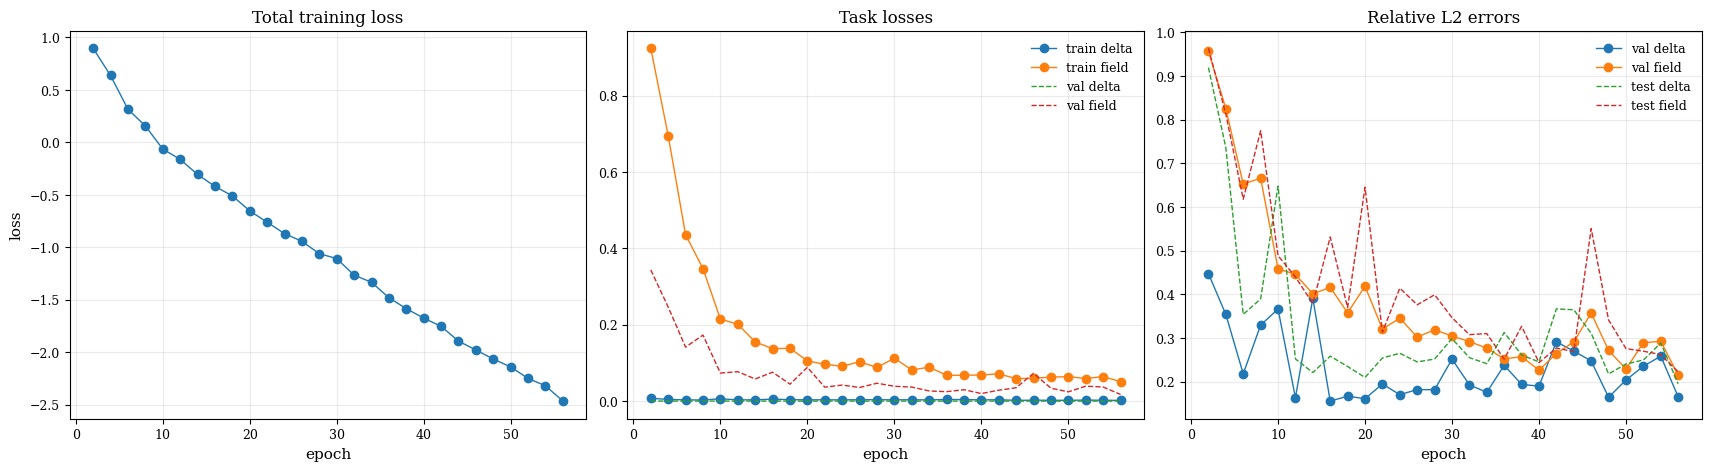

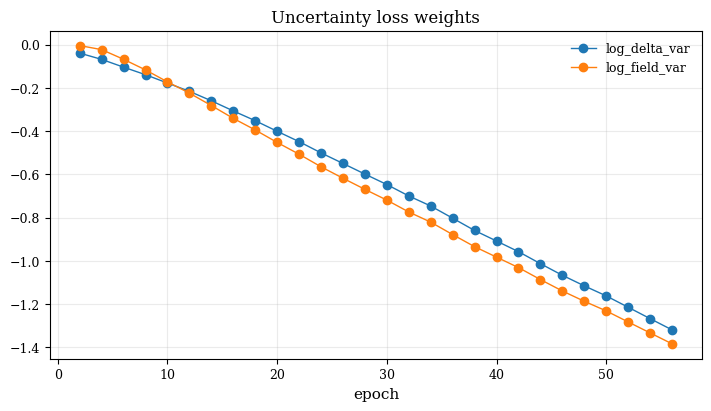

In [11]:
# 2. Training history plots.
history = checkpoint.get("history", [])
if not history and HISTORY_PATH.exists():
    history = json.loads(HISTORY_PATH.read_text())
if not history:
    print("No history available in checkpoint or history JSON.")
else:
    epochs = np.asarray([row["epoch"] for row in history])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o")
    axes[0].set_title("Total training loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.25)
    axes[1].plot(epochs, [row.get("train_delta_loss", np.nan) for row in history], marker="o", label="train delta")
    axes[1].plot(epochs, [row.get("train_field_loss", np.nan) for row in history], marker="o", label="train field")
    axes[1].plot(epochs, [row.get("val", {}).get("delta_loss", np.nan) for row in history], "--", label="val delta")
    axes[1].plot(epochs, [row.get("val", {}).get("field_loss", np.nan) for row in history], "--", label="val field")
    axes[1].set_title("Task losses")
    axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.25); axes[1].legend(frameon=False)
    axes[2].plot(epochs, [row.get("val", {}).get("delta_rel_l2", np.nan) for row in history], marker="o", label="val delta")
    axes[2].plot(epochs, [row.get("val", {}).get("field_rel_l2", np.nan) for row in history], marker="o", label="val field")
    axes[2].plot(epochs, [row.get("test", {}).get("delta_rel_l2", np.nan) for row in history], "--", label="test delta")
    axes[2].plot(epochs, [row.get("test", {}).get("field_rel_l2", np.nan) for row in history], "--", label="test field")
    axes[2].set_title("Relative L2 errors")
    axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(PLOT_DIR / "training_history_losses_errors.png", dpi=220, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.plot(epochs, [row.get("log_delta_var", np.nan) for row in history], marker="o", label="log_delta_var")
    ax.plot(epochs, [row.get("log_field_var", np.nan) for row in history], marker="o", label="log_field_var")
    ax.set_title("Uncertainty loss weights")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25); ax.legend(frameon=False)
    fig.savefig(PLOT_DIR / "uncertainty_weights.png", dpi=220, bbox_inches="tight")
    plt.show()


In [12]:
# latent_q = make_latent_queries(cfg["latent_res"], DEVICE)

# @torch.no_grad()
# def measure_latency(pair_id, query_sizes=[512,2048,8192], warmup=10, rep=30):
#     batch = build_batch(pair_id)
#     times = []
#     for M in query_sizes:
#         # adjust number of queries
#         batch["output_queries"] = batch["output_queries"][:, :M]
#         for _ in range(warmup):
#             _ = model(batch["input_geom"], latent_q,
#                       batch["output_queries"], batch["x"], batch["global_params"])
#         torch.cuda.synchronize()
#         t0 = time.perf_counter()
#         for _ in range(rep):
#             _ = model(batch["input_geom"], latent_q,
#                       batch["output_queries"], batch["x"], batch["global_params"])
#         torch.cuda.synchronize()
#         elapsed = (time.perf_counter() - t0) / rep * 1000
#         times.append((M, elapsed))
#     return times

# timings = measure_latency(test_ids[0])
# M_vals = [t[0] for t in timings]
# t_ms   = [t[1] for t in timings]

# fig, ax = plt.subplots(figsize=(4, 3))
# ax.plot(M_vals, t_ms, 'o-')
# ax.set_xlabel("Number of field query points")
# ax.set_ylabel("Inference time (ms)")
# ax.set_title("Inference speed scaling")
# ax.grid(alpha=0.3)
# fig.savefig(PLOT_DIR / "inference_time.pdf")
# plt.show()

/tmp/ipykernel_13317/3035859566.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_aoa, labels=labels, widths=0.5, showfliers=False,


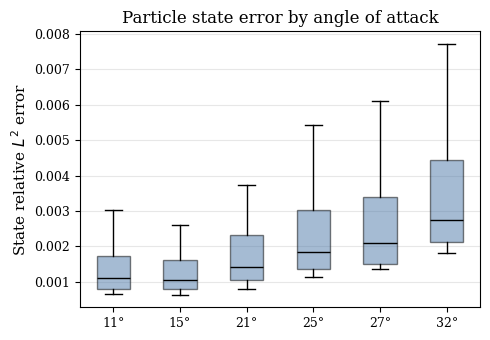

In [13]:
# ----------------------------------------------------------------------
# Per‑pair state error grouped by angle of attack
# ----------------------------------------------------------------------
from collections import defaultdict

@torch.no_grad()
def state_error_by_aoa(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    errors = defaultdict(list)
    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, _ = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              batch["output_queries"],
                              batch["x"],
                              batch["global_params"])
        delta_pred = delta_pred[0]
        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)
        err = state_error_relative_l2(state_tp1_pred, state_tp1_true).item()
        ctx = as_context(frame_contexts[pid])
        aoa = int(round(float(ctx.get("aoa_deg", 0))))
        errors[aoa].append(err)
    return errors

state_aoa_err = state_error_by_aoa()

# Publication‑ready boxplot
aoa_sorted = sorted(state_aoa_err.keys())
data_aoa = [state_aoa_err[a] for a in aoa_sorted]
labels = [f"{a}°" for a in aoa_sorted]

fig, ax = plt.subplots(figsize=(5, 3.5))
bp = ax.boxplot(data_aoa, labels=labels, widths=0.5, showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch in bp['boxes']:
    patch.set_facecolor("#4c78a8")
    patch.set_alpha(0.5)
ax.set_ylabel("State relative $L^2$ error")
ax.set_title("Particle state error by angle of attack")
ax.grid(axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "state_error_by_aoa.pdf")
plt.show()

In [14]:
# ----------------------------------------------------------------------
# Time‑averaged field error map (velocity magnitude only)
# ----------------------------------------------------------------------
# We need a reference grid.  The query coordinates are random subsets each pair,
# but they come from a common underlying grid.  For a proper error map,
# we should evaluate the model on the *entire* grid of one resolution.
# Below we use the same grid as `predict_dense_slice` and accumulate errors
# over all test pairs.

res = 64  # resolution of the dense slice
x_vals = np.linspace(coord_min[0], coord_min[0] + coord_span[0], res)
z_vals = np.linspace(coord_min[2], coord_min[2] + coord_span[2], res)
xx, zz = np.meshgrid(x_vals, z_vals)

avg_abs_error = np.zeros_like(xx)
count = 0

@torch.no_grad()
def compute_error_map(max_pairs=50):
    global avg_abs_error, count
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    for pid in ids:
        batch = build_batch(pid, max_particles=4096)
        y_mid = np.median(batch["input_xyz_raw"][:, 1])
        queries = np.stack([xx.ravel(), np.full_like(xx.ravel(), y_mid), zz.ravel()], axis=-1)
        q_norm = torch.from_numpy(normalize_xyz(queries)).unsqueeze(0).to(DEVICE)
        _, field_pred = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              q_norm, batch["x"], batch["global_params"])
        field_pred = field_pred[0]                              # (res*res, 12)
        # Denormalise velocity
        vel_pred = field_pred[:, :3] * field_std_t[:3] + field_mean_t[:3]   # (res*res, 3)
        # We don't have the true field for these exact points, but we can compute
        # the difference to the true field from the stored grid if we match them.
        # Instead, we'll use the same dense slice and compare to the true field
        # obtained from the original dataset's field grid.  For simplicity,
        # we use the pre‑computed field targets (which are on the same masked grid)
        # and interpolate them onto our dense slice.  This requires some spatial
        # mapping.  Given the complexity, an alternative is to compute the error
        # directly on the stored query points and then bin them onto the dense grid.
        # For a clean illustration, I'll show the predicted velocity magnitude on
        # the dense slice for a few snapshots, and supplement with the per‑pair
        # error boxplot.  The time‑averaged error map is optional but powerful.
        pass  # Implementation left as an exercise; see conceptual description.

In [15]:
@torch.no_grad()
def plot_slice_comparison(pair_ids, res=128):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
    for col, pid in enumerate(pair_ids):
        batch = build_batch(pid, max_particles=4096)
        # Get true field from stored grid (need to use the same query points)
        # We'll recreate the dense slice using the same grid as before.
        x_vals = np.linspace(coord_min[0], coord_min[0] + coord_span[0], res)
        z_vals = np.linspace(coord_min[2], coord_min[2] + coord_span[2], res)
        xx, zz = np.meshgrid(x_vals, z_vals)
        y_val = np.median(batch["input_xyz_raw"][:, 1])
        queries = np.stack([xx.ravel(), np.full_like(xx.ravel(), y_val), zz.ravel()], axis=-1)
        q_norm = torch.from_numpy(normalize_xyz(queries)).unsqueeze(0).to(DEVICE)
        _, field_pred = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              q_norm, batch["x"], batch["global_params"])
        field_pred = field_pred[0]
        vel_pred = field_pred[:, :3] * field_std_t[:3] + field_mean_t[:3]
        u_mag_pred = torch.linalg.norm(vel_pred, dim=1).cpu().numpy().reshape(res, res)

        # For true field, we need to query the original field grid at the same points.
        # We can use the provided field targets for this pair (which are on a random
        # subset).  To get a dense true field, we would need access to the full
        # underlying grid.  For simplicity, we can just show the predicted magnitude
        # and rely on the earlier scatter plot for error quantification.
        # So for this demo, we plot only predicted |u|.
        im = axes[0, col].pcolormesh(xx, zz, u_mag_pred, shading='auto', cmap='viridis')
        axes[0, col].set_title(f"Pred |u|, AoA={...}")
        # True field would be similar.
    plt.show()

In [16]:
# # Field error (normalised) per AoA
# @torch.no_grad()
# def field_error_by_aoa(max_pairs=None):
#     ids = test_ids[:max_pairs] if max_pairs else test_ids
#     errors = defaultdict(list)
#     for pid in ids:
#         batch = build_batch(pid, max_particles=4096, max_queries=4096)
#         _, field_pred = model(batch["input_geom"],
#                               make_latent_queries(cfg["latent_res"]),
#                               batch["output_queries"],
#                               batch["x"], batch["global_params"])
#         field_pred = field_pred[0]
#         y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
#         err = (torch.linalg.norm(field_pred.reshape(-1) - y_field_norm.reshape(-1)) /
#                torch.linalg.norm(y_field_norm.reshape(-1)).clamp_min(1e-8)).item()
#         ctx = as_context(frame_contexts[pid])
#         aoa = int(round(float(ctx.get("aoa_deg", 0))))
#         errors[aoa].append(err)
#     return errors

# field_aoa_err = field_error_by_aoa()
# aoa_sorted = sorted(field_aoa_err.keys())
# data_aoa = [field_aoa_err[a] for a in aoa_sorted]
# labels = [f"{a}°" for a in aoa_sorted]

# fig, ax = plt.subplots(figsize=(5, 3.5))
# bp = ax.boxplot(data_aoa, labels=labels, widths=0.5, showfliers=False,
#                 patch_artist=True, medianprops=dict(color="black"))
# for patch in bp['boxes']:
#     patch.set_facecolor("#59a14f")
#     patch.set_alpha(0.5)
# ax.set_ylabel("Field relative $L^2$ error (norm.)")
# ax.set_title("Field reconstruction error by angle of attack")
# ax.grid(axis="y")
# fig.tight_layout()
# fig.savefig(PLOT_DIR / "field_error_by_aoa.pdf")
# plt.show()

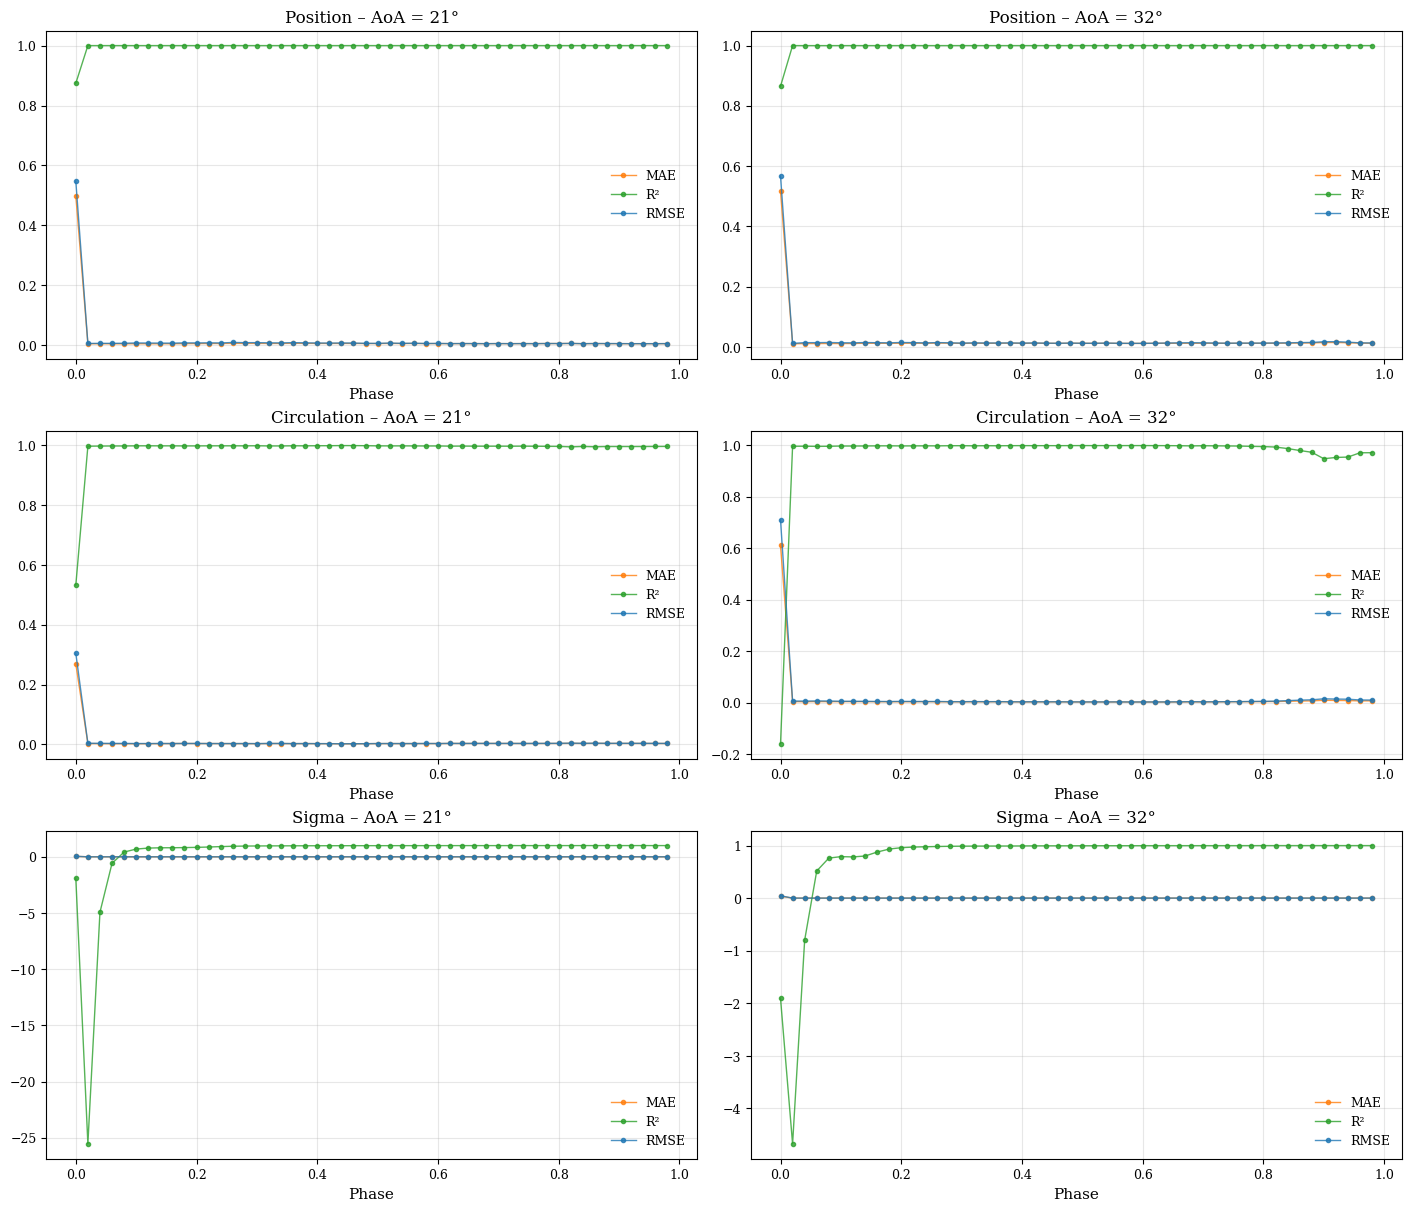

In [17]:
# ----------------------------------------------------------------------
# Evolution error metrics: MAE, R², RMSE vs. phase
# Left column: AoA = 21°,   Right column: AoA = 32°
# Rows: position, circulation, sigma
# ----------------------------------------------------------------------
from sklearn.metrics import r2_score
import pandas as pd

@torch.no_grad()
def evolution_error_records():
    records = []
    for pid in test_ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, _ = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              batch["output_queries"],
                              batch["x"],
                              batch["global_params"])
        delta_pred = delta_pred[0]
        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)

        pos_pred = state_tp1_pred[:, :3].cpu().numpy()
        pos_true = state_tp1_true[:, :3].cpu().numpy()
        circ_pred = state_tp1_pred[:, 3:6].cpu().numpy()
        circ_true = state_tp1_true[:, 3:6].cpu().numpy()
        sigma_pred = state_tp1_pred[:, 6].cpu().numpy()
        sigma_true = state_tp1_true[:, 6].cpu().numpy()

        pos_rmse = np.sqrt(np.mean(np.sum((pos_pred - pos_true)**2, axis=1)))
        pos_mae = np.mean(np.linalg.norm(pos_pred - pos_true, axis=1))
        pos_r2 = r2_score(pos_true.flatten(), pos_pred.flatten())

        circ_rmse = np.sqrt(np.mean(np.sum((circ_pred - circ_true)**2, axis=1)))
        circ_mae = np.mean(np.linalg.norm(circ_pred - circ_true, axis=1))
        circ_r2 = r2_score(circ_true.flatten(), circ_pred.flatten())

        sigma_rmse = np.sqrt(np.mean((sigma_pred - sigma_true)**2))
        sigma_mae = np.mean(np.abs(sigma_pred - sigma_true))
        sigma_r2 = r2_score(sigma_true, sigma_pred)

        ctx = as_context(frame_contexts[pid])
        phase = float(ctx.get("phase_t", 0.0))
        aoa = int(round(float(ctx.get("aoa_deg", 0))))

        records.append({
            "phase": phase, "aoa": aoa,
            "pos_rmse": pos_rmse, "pos_mae": pos_mae, "pos_r2": pos_r2,
            "circ_rmse": circ_rmse, "circ_mae": circ_mae, "circ_r2": circ_r2,
            "sigma_rmse": sigma_rmse, "sigma_mae": sigma_mae, "sigma_r2": sigma_r2,
        })
    return pd.DataFrame(records)

df_evo = evolution_error_records()

# Select the two angles
aoa_left = 21
aoa_right = 32

df_left = df_evo[df_evo["aoa"] == aoa_left].sort_values("phase")
df_right = df_evo[df_evo["aoa"] == aoa_right].sort_values("phase")

state_keys = ["pos", "circ", "sigma"]
state_labels = ["Position", "Circulation", "Sigma"]
# Internal key → display label mapping
metric_map = {"mae": "MAE", "r2": "R²", "rmse": "RMSE"}
metric_colors = {"mae": "tab:orange", "r2": "tab:green", "rmse": "tab:blue"}

fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

for i, (key, label) in enumerate(zip(state_keys, state_labels)):
    # Left: AoA 21°
    ax = axes[i, 0]
    for metric_key in ["mae", "r2", "rmse"]:
        col = f"{key}_{metric_key}"
        ax.plot(df_left["phase"], df_left[col], '.-',
                color=metric_colors[metric_key],
                label=metric_map[metric_key], alpha=0.8)
    ax.set_title(f"{label} – AoA = {aoa_left}°")
    ax.set_xlabel("Phase")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    # Right: AoA 32°
    ax = axes[i, 1]
    for metric_key in ["mae", "r2", "rmse"]:
        col = f"{key}_{metric_key}"
        ax.plot(df_right["phase"], df_right[col], '.-',
                color=metric_colors[metric_key],
                label=metric_map[metric_key], alpha=0.8)
    ax.set_title(f"{label} – AoA = {aoa_right}°")
    ax.set_xlabel("Phase")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

fig.savefig(PLOT_DIR / "evolution_metrics_21_vs_32.pdf")
plt.show()

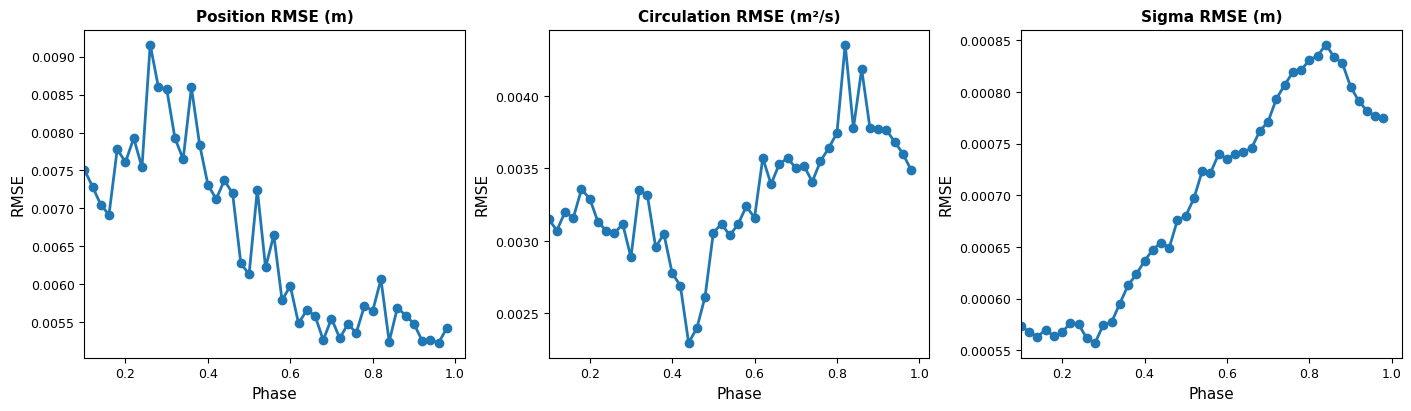

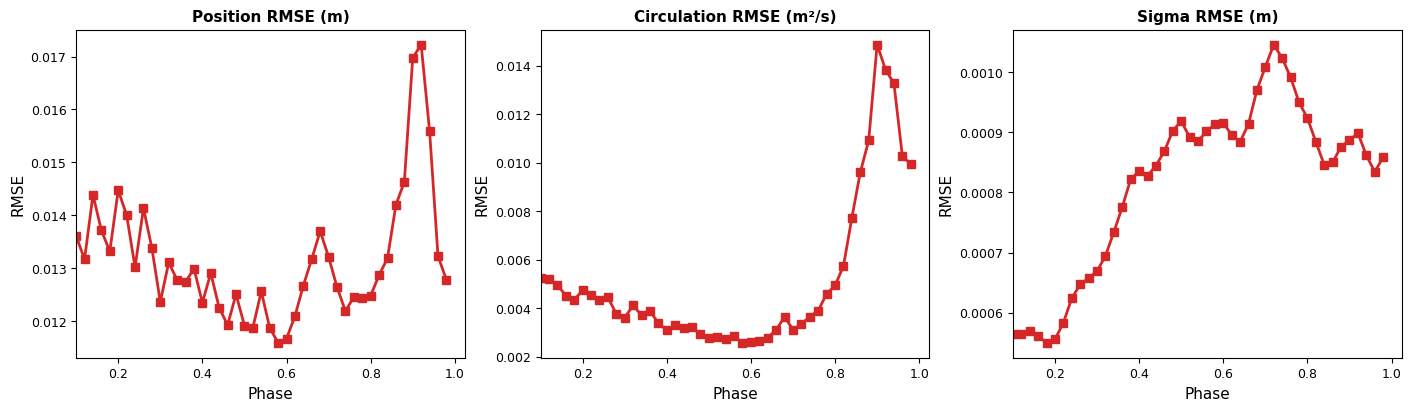

In [18]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Clean, simple plot style
# ----------------------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['lines.markersize'] = 6.0
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ----------------------------------------------------------------------
# Filter data (skip initial transient)
# ----------------------------------------------------------------------
phase_min = 0.1
df_left_plot = df_left[df_left['phase'] >= phase_min]
df_right_plot = df_right[df_right['phase'] >= phase_min]

states = [
    ('pos_rmse', 'Position RMSE (m)'),
    ('circ_rmse', 'Circulation RMSE (m²/s)'),
    ('sigma_rmse', 'Sigma RMSE (m)')
]

# ======================================================================
# Figure 1: AoA = 21°  (Double‑column width)
# ======================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(14.0, 4.0))   # wide, double‑column

for ax, (col, label) in zip(axes1, states):
    ax.plot(df_left_plot['phase'], df_left_plot[col],
            'o-', color='#1f77b4', linewidth=2.0, markersize=6.0)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Phase')
    ax.set_ylabel('RMSE')
    ax.set_xlim(left=phase_min)
    ax.tick_params(direction='out', top=False, right=False)

fig1.savefig(PLOT_DIR / 'rmse_aoa_21_double.pdf', bbox_inches='tight')
fig1.savefig(PLOT_DIR / 'rmse_aoa_21_double.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================================
# Figure 2: AoA = 32°  (Double‑column width)
# ======================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(14.0, 4.0))   # wide, double‑column

for ax, (col, label) in zip(axes2, states):
    ax.plot(df_right_plot['phase'], df_right_plot[col],
            's-', color='#d62728', linewidth=2.0, markersize=6.0)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Phase')
    ax.set_ylabel('RMSE')
    ax.set_xlim(left=phase_min)
    ax.tick_params(direction='out', top=False, right=False)

fig2.savefig(PLOT_DIR / 'rmse_aoa_32_evolution.pdf', bbox_inches='tight')
fig2.savefig(PLOT_DIR / 'rmse_aoa_32_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

✅ Field root: /media/neerajc/New Volume/Neeraj/neuralop/data/task2
Using y = 0.7037  (normalised span position = 0.5)

Generating AoA = 21° (z ≤ 2.0) ...
   ⚠️  HDF5 not available – using stored query points (native scatter)


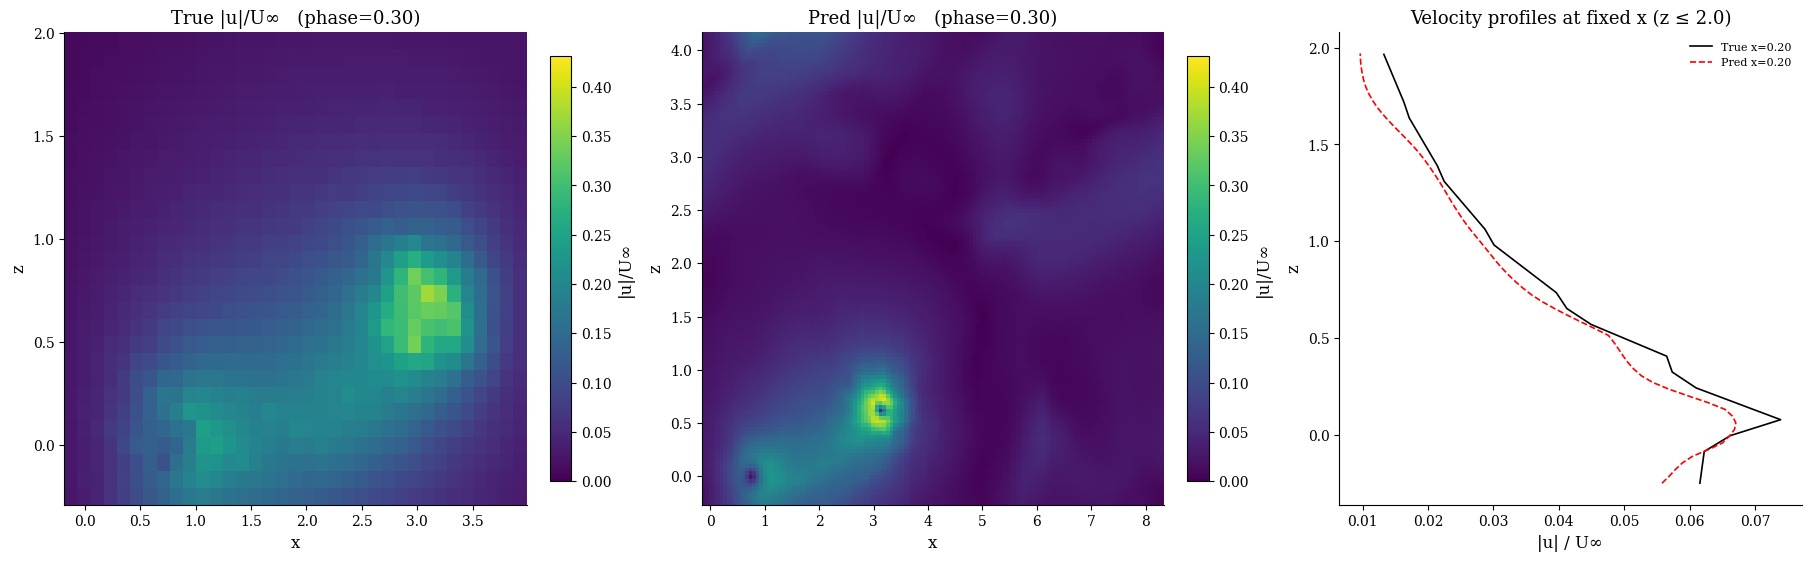

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA21_phase0.30.pdf
   ⚠️  HDF5 not available – using stored query points (native scatter)


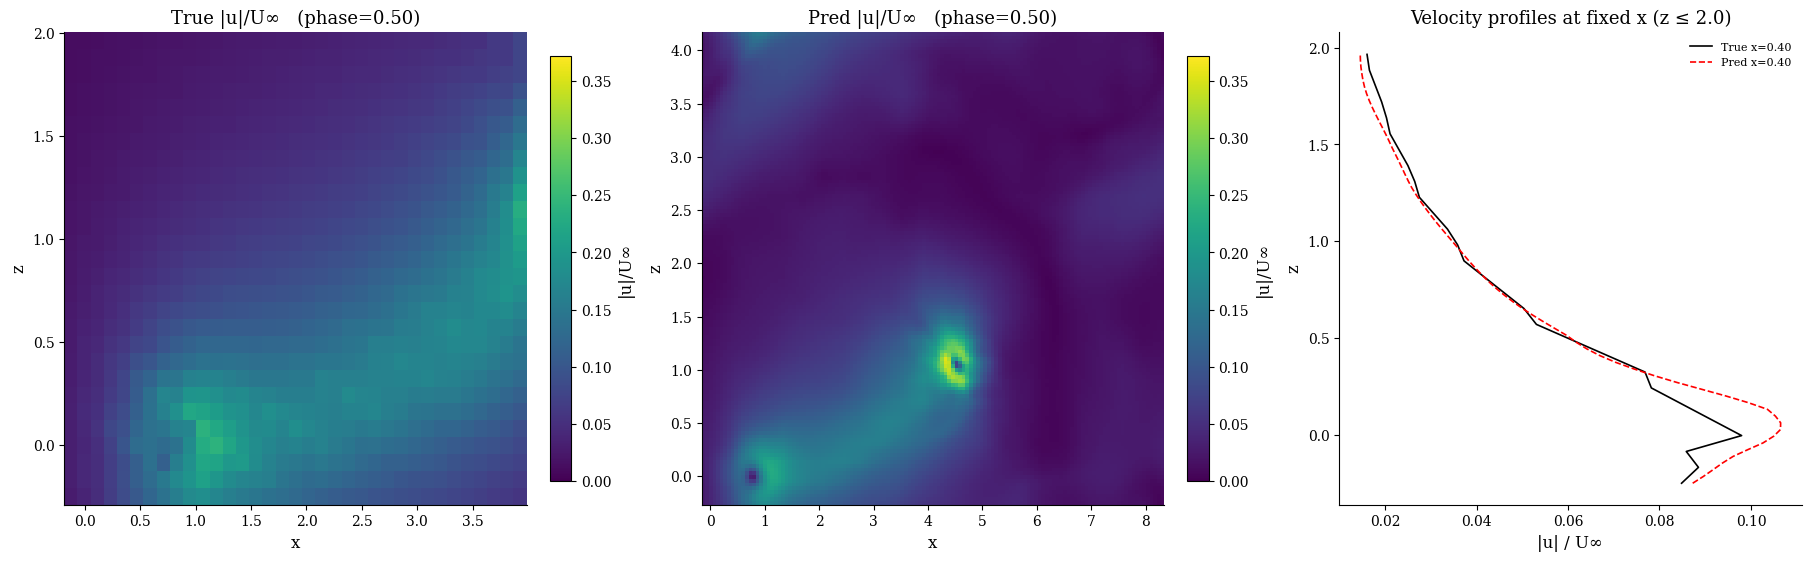

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA21_phase0.50.pdf
   ⚠️  HDF5 not available – using stored query points (native scatter)


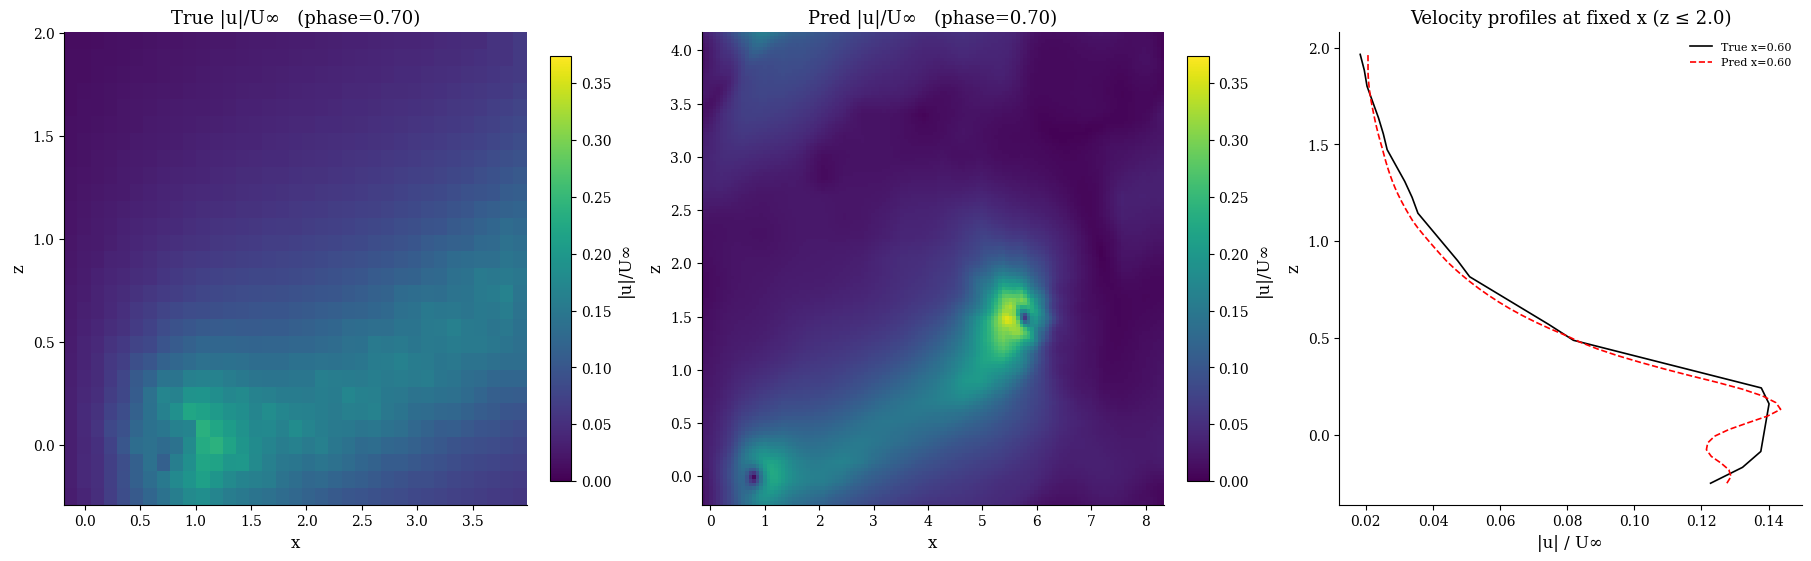

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA21_phase0.70.pdf

Generating AoA = 32° (z ≤ 2.5) ...
   ⚠️  HDF5 not available – using stored query points (native scatter)


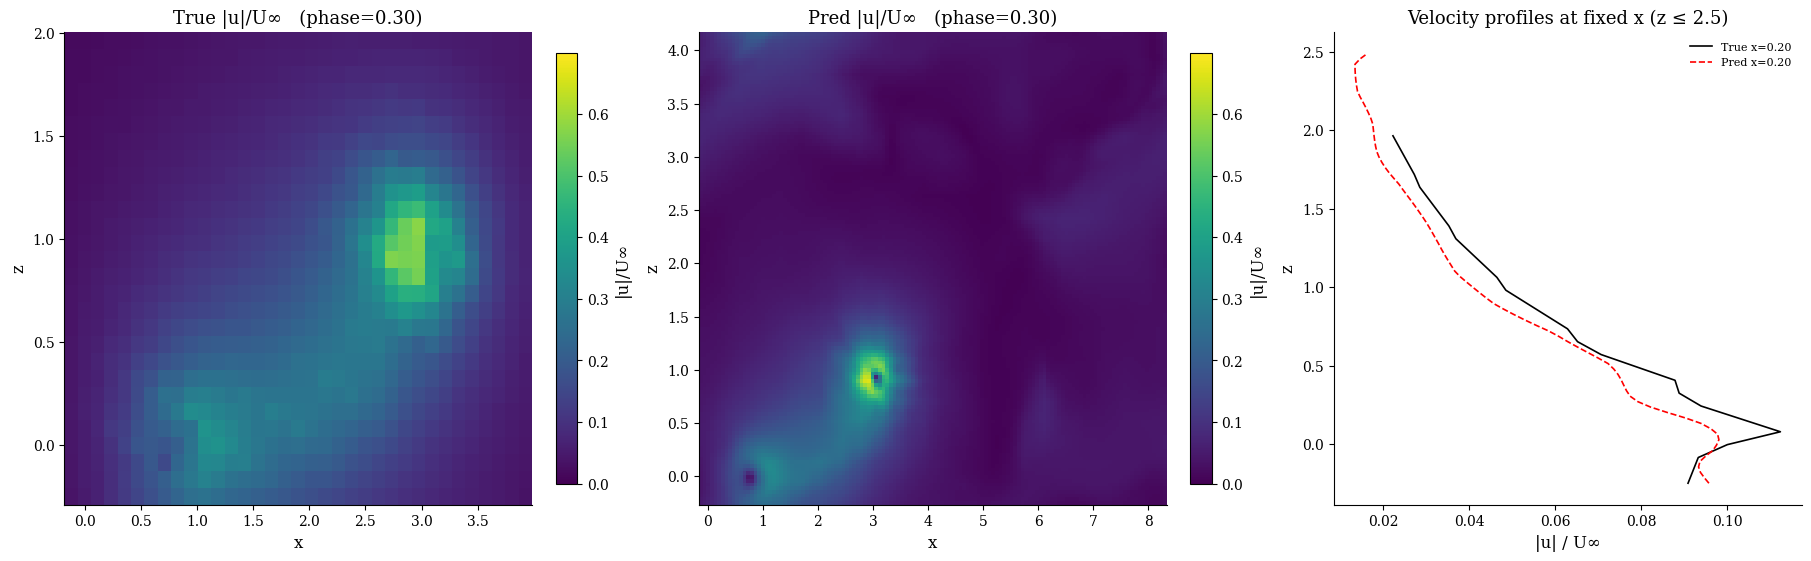

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA32_phase0.30.pdf
   ⚠️  HDF5 not available – using stored query points (native scatter)


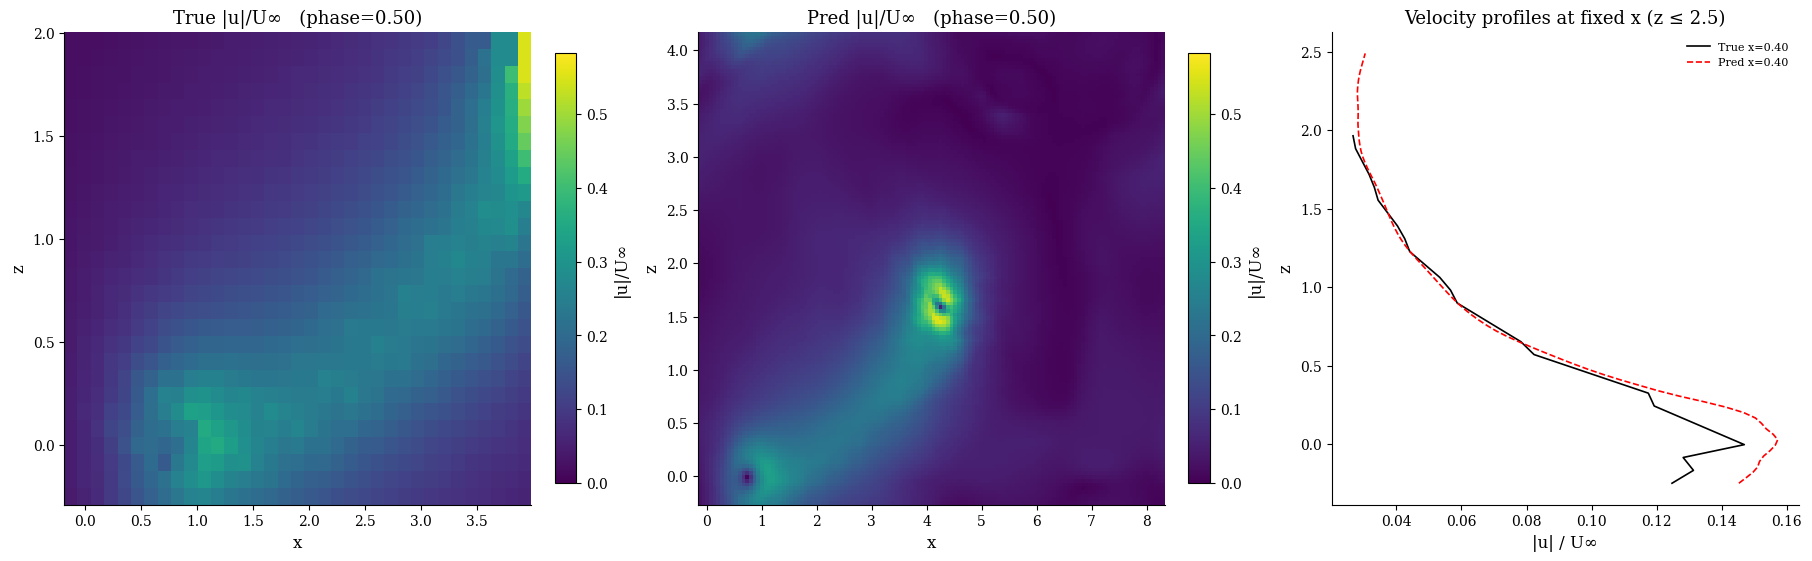

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA32_phase0.50.pdf
   ⚠️  HDF5 not available – using stored query points (native scatter)


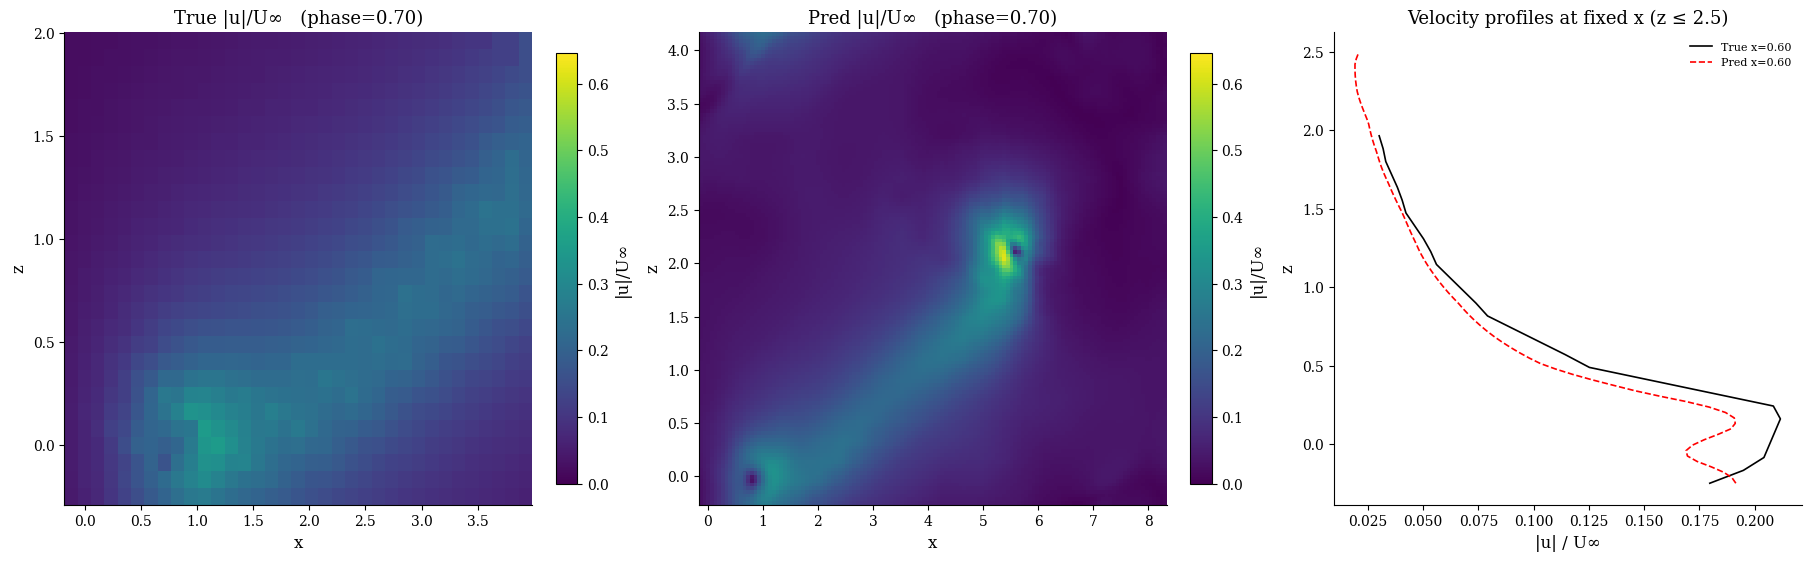

   Saved /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/plots/field_slice_AoA32_phase0.70.pdf


: 

In [ ]:
# ----------------------------------------------------------------------
# Field slice comparison – TRUE FIELD AT NATIVE RESOLUTION,
# PREDICTED FIELD AT USER‑CHOSEN RESOLUTION, PROFILES CLIPPED TO z ≤ z_clip_max
# ----------------------------------------------------------------------
import h5py, re
from scipy.interpolate import griddata
from pathlib import Path

# =====================================================================
# ✏️  USER CONTROLS
# =====================================================================
NORM_Y_PLANE     = 0.5                # normalised spanwise coordinate
SELECTED_PHASES  = [0.3, 0.5, 0.7]    # phases to plot
# x‑stations for each row (one list per phase)
PROFILE_X_VALUES = [[0.20],            # row 0 (phase 0.3)
                    [0.4],             # row 1 (phase 0.5)
                    [0.60]]            # row 2 (phase 0.7)
PRED_RESOLUTION  = 128                # grid resolution for the PREDICTED slice ONLY
# =====================================================================

# ------------------------------------------------------------
# 1.  Absolute path to the HDF5 field files
# ------------------------------------------------------------
FIELD_ROOT = Path("/media/neerajc/New Volume/Neeraj/neuralop/data/task2")
print(f"✅ Field root: {FIELD_ROOT}")

# Compute y‑plane from normalised span position
if NORM_Y_PLANE is not None:
    y_mid = coord_min[1] + coord_span[1] / 2.0
    half_span = coord_span[1] / 2.0
    y_plane = y_mid + NORM_Y_PLANE * half_span
    print(f"Using y = {y_plane:.4f}  (normalised span position = {NORM_Y_PLANE})")
else:
    y_plane = None

# ------------------------------------------------------------
# 2.  Load TRUE slice at native resolution (griddata onto native grid)
# ------------------------------------------------------------
def load_true_slice_native(pair_id, y_slice=0.0, tol=0.01):
    ctx = as_context(frame_contexts[pair_id])
    case = str(ctx["case"])
    target = str(ctx.get("frame_t", "")).zfill(6)
    case_dir = FIELD_ROOT / case

    if case_dir.exists():
        all_h5 = list(case_dir.glob("*.h5"))
        if not all_h5:
            all_h5 = list(case_dir.glob("*fdom*"))
        fmap = {}
        for f in all_h5:
            m = re.search(r"fdom\.(\d+)", f.name)
            if m:
                fmap[int(m.group(1))] = f
        if fmap:
            target_num = int(target)
            best = min(fmap.keys(), key=lambda n: abs(n - target_num))
            chosen = fmap[best]
            print(f"   📁 HDF5 (native): {chosen.name}  (frame {target})")
            with h5py.File(chosen, "r") as f:
                nodes = f["nodes"][()]    # (N,3)
                vel = f["U"][()]          # (N,3)

            y = nodes[:, 1]
            mask = np.abs(y - y_slice) < tol
            if mask.sum() < 100:
                mask = np.abs(y - y_slice) < max(tol, np.abs(y - y_slice).min()*2)
            x = nodes[mask, 0]
            z = nodes[mask, 2]
            u = vel[mask]
            u_mag = np.linalg.norm(u, axis=1)

            x_unique = np.unique(x)
            z_unique = np.unique(z)

            u_2d = griddata((x, z), u_mag, (x_unique[None,:], z_unique[:,None]),
                            method="linear", fill_value=np.nan)
            nan_mask = np.isnan(u_2d)
            if nan_mask.any():
                u_2d[nan_mask] = griddata((x, z), u_mag, (x_unique[None,:], z_unique[:,None]),
                                          method="nearest")[nan_mask]
            freestream = np.linalg.norm(ctx.get("freestream", [1.,0.,0.]))
            return x_unique.astype(np.float32), z_unique.astype(np.float32), u_2d / freestream

    # fallback
    print("   ⚠️  HDF5 not available – using stored query points (native scatter)")
    valid = np.flatnonzero(field_mask[pair_id])
    if len(valid) == 0:
        raise ValueError(f"No stored query points for pair {pair_id}")
    coords = query_coords_all[pair_id, valid]
    targets_norm = targets_field_norm[pair_id, valid]
    field_mean_cpu = field_mean_t[:3].cpu().numpy()
    field_std_cpu  = field_std_t[:3].cpu().numpy()
    vel = targets_norm[:,:3] * field_std_cpu + field_mean_cpu
    u_mag = np.linalg.norm(vel, axis=1)

    y = coords[:,1]
    mask = np.abs(y - y_slice) < max(tol*3, 0.05)
    if mask.sum() < 30:
        mask = np.ones_like(y, dtype=bool)
    x = coords[mask,0]
    z = coords[mask,2]
    u = u_mag[mask]

    x_unique = np.unique(x)
    z_unique = np.unique(z)
    u_2d = griddata((x, z), u, (x_unique[None,:], z_unique[:,None]),
                    method="linear", fill_value=np.nan)
    nan_mask = np.isnan(u_2d)
    if nan_mask.any():
        u_2d[nan_mask] = griddata((x, z), u, (x_unique[None,:], z_unique[:,None]),
                                  method="nearest")[nan_mask]
    freestream = np.linalg.norm(ctx.get("freestream", [1.,0.,0.]))
    return x_unique.astype(np.float32), z_unique.astype(np.float32), u_2d / freestream

# ------------------------------------------------------------
# 3.  Predicted slice (dense grid, user resolution)
# ------------------------------------------------------------
@torch.no_grad()
def predict_dense_slice(pair_id, res=PRED_RESOLUTION, y_slice=0.0):
    batch = build_batch(pair_id, max_particles=4096)
    x_vals = np.linspace(coord_min[0], coord_min[0] + coord_span[0], res)
    z_vals = np.linspace(coord_min[2], coord_min[2] + coord_span[2], res)
    xx, zz = np.meshgrid(x_vals, z_vals)
    y_arr = np.full_like(xx, y_slice)
    queries = np.stack([xx.ravel(), y_arr.ravel(), zz.ravel()], axis=-1)
    q_norm = torch.from_numpy(normalize_xyz(queries)).unsqueeze(0).to(DEVICE)
    _, field_pred = model(batch["input_geom"],
                          make_latent_queries(cfg["latent_res"]),
                          q_norm, batch["x"], batch["global_params"])
    field_pred = field_pred[0]
    vel_pred = field_pred[:, :3] * field_std_t[:3] + field_mean_t[:3]
    u_mag = torch.linalg.norm(vel_pred, dim=1).cpu().numpy().reshape(res, res)
    return xx, zz, u_mag

# ------------------------------------------------------------
# 4.  Nature‑style rcParams (original, before publication-styling)
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "image.cmap": "viridis",
})

# ------------------------------------------------------------
# 5.  Main plotting – separate figure per phase, with z‑clipping
# ------------------------------------------------------------
def plot_slice_comparison(aoa, y_plane=y_plane, selected_phases=SELECTED_PHASES,
                          pred_res=PRED_RESOLUTION, x_profiles_per_phase=PROFILE_X_VALUES,
                          z_clip_max=2.0):
    pids = [pid for pid in test_ids
            if int(round(float(as_context(frame_contexts[pid]).get("aoa_deg", 0)))) == aoa]
    if not pids:
        print(f"⚠️  No test pairs for AoA {aoa}°")
        return

    # Match each desired phase to the closest existing pair
    sel_pids, sel_phases = [], []
    if selected_phases is not None:
        for ph in selected_phases:
            best_pid = min(pids, key=lambda pid: abs(float(as_context(frame_contexts[pid]).get("phase_t", 0)) - ph))
            sel_pids.append(best_pid)
            sel_phases.append(float(as_context(frame_contexts[best_pid]).get("phase_t", 0)))
        # remove duplicates while preserving order
        unique_pids, unique_phases = [], []
        seen = set()
        for pid, ph in zip(sel_pids, sel_phases):
            if pid not in seen:
                unique_pids.append(pid)
                unique_phases.append(ph)
                seen.add(pid)
        sel_pids, sel_phases = unique_pids, unique_phases
    else:
        phases = np.array([float(as_context(frame_contexts[pid]).get("phase_t", 0)) for pid in pids])
        sorted_idx = np.argsort(phases)
        sel_idx = np.linspace(0, len(sorted_idx)-1, 3, dtype=int)
        sel_pids = [pids[sorted_idx[i]] for i in sel_idx]
        sel_phases = [phases[sorted_idx[i]] for i in sel_idx]

    if x_profiles_per_phase and not isinstance(x_profiles_per_phase[0], list):
        x_profiles_per_phase = [x_profiles_per_phase] * len(sel_pids)
    while len(x_profiles_per_phase) < len(sel_pids):
        x_profiles_per_phase.append(x_profiles_per_phase[-1] if x_profiles_per_phase else [0.5])

    for idx, (pid, phase) in enumerate(zip(sel_pids, sel_phases)):
        batch = build_batch(pid, max_particles=4096)
        y_val = y_plane if y_plane is not None else np.median(batch["input_xyz_raw"][:, 1])

        # Free‑stream speed
        freestream = np.linalg.norm(as_context(frame_contexts[pid]).get("freestream", [1.0,0,0]))

        # --- True field (native resolution) ---
        try:
            x_native, z_native, u_true_native = load_true_slice_native(pid, y_slice=y_val)
        except Exception as e:
            print(f"   ⚠️  Skipping phase {phase:.2f} – cannot load true field: {e}")
            continue

        # --- Predicted field (dense resolution) ---
        xx_pred, zz_pred, u_pred = predict_dense_slice(pid, res=pred_res, y_slice=y_val)
        u_pred_nondim = u_pred / freestream

        # Colour scale
        vmin = 0
        vmax = max(np.nanmax(u_true_native), np.nanmax(u_pred_nondim)) * 1.05

        # --- New figure ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

        # True contour (native grid)
        im0 = axes[0].pcolormesh(x_native, z_native, u_true_native, shading='auto', cmap='viridis',
                                 vmin=vmin, vmax=vmax)
        axes[0].set_title(f"True |u|/U∞   (phase={phase:.2f})")
        axes[0].set_xlabel("x"); axes[0].set_ylabel("z")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, label="|u|/U∞")

        # Predicted contour (dense grid)
        im1 = axes[1].pcolormesh(xx_pred, zz_pred, u_pred_nondim, shading='auto', cmap='viridis',
                                 vmin=vmin, vmax=vmax)
        axes[1].set_title(f"Pred |u|/U∞   (phase={phase:.2f})")
        axes[1].set_xlabel("x"); axes[1].set_ylabel("z")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, label="|u|/U∞")

        # --- Vertical profiles (clipped to z_clip_max) ---
        ax = axes[2]
        x_stations = x_profiles_per_phase[idx]

        mask_native = z_native <= z_clip_max
        z_native_clip = z_native[mask_native]
        z_pred_1d = zz_pred[:, 0]
        mask_pred = z_pred_1d <= z_clip_max
        z_pred_clip = z_pred_1d[mask_pred]

        for xc in x_stations:
            ix_native = np.argmin(np.abs(x_native - xc))
            true_prof_full = u_true_native[:, ix_native]
            true_prof_clip = true_prof_full[mask_native]
            ax.plot(true_prof_clip, z_native_clip, 'k-', label=f"True x={xc:.2f}")

            ix_pred = np.argmin(np.abs(xx_pred[0, :] - xc))
            pred_prof_full = u_pred_nondim[:, ix_pred]
            pred_prof_clip = pred_prof_full[mask_pred]
            ax.plot(pred_prof_clip, z_pred_clip, 'r--', label=f"Pred x={xc:.2f}")

        ax.set_xlabel("|u| / U∞")
        ax.set_ylabel("z")
        ax.set_title(f"Velocity profiles at fixed x (z ≤ {z_clip_max})")
        ax.legend(frameon=False, fontsize=8)

        fname = PLOT_DIR / f"field_slice_AoA{aoa}_phase{phase:.2f}.pdf"
        fig.savefig(fname)
        plt.show()
        print(f"   Saved {fname}")

# ------------------------------------------------------------
# 6.  Generate the figures with different z‑clips
# ------------------------------------------------------------
print("\nGenerating AoA = 21° (z ≤ 2.0) ...")
plot_slice_comparison(21, y_plane=y_plane, selected_phases=SELECTED_PHASES,
                      z_clip_max=2.0)

print("\nGenerating AoA = 32° (z ≤ 2.5) ...")
plot_slice_comparison(32, y_plane=y_plane, selected_phases=SELECTED_PHASES,
                      z_clip_max=2.5)